In [1]:
import pandas as pd 
import matplotlib

In [7]:
with open("out_assignment1.out", "r") as f:
    data = f.read()

print(data)


Filesystems usage for user maemel ( uid 646320632 ):
-------------------------------------------------------------------------------------
Directory                       Used   Limit   Used,%         Files     Limit
-------------------------------------------------------------------------------------
/home/maemel                    28KB    15GB     0.0%            34    100000
/data/maemel                    11GB   200GB     5.4%         40219          
/scratch/maemel                   0B    20TB     0.0%             1          

/shares/atomt.pilot.s3it.uzh   1.4GB    10TB     0.0%            13          
-------------------------------------------------------------------------------------

Files on /scratch may be purged after 30 days.
See https://docs.s3it.uzh.ch/cluster/data

sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=/home/maemel/shares/cz-en/data/raw/train.cz --model_prefix=cz-bpe-8000 --pad_id=3 --vocab_size=8000 --model_type=bpe --unk_piece=<unk> --bos_

In [11]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# читаем лог
with open("out_assignment1.out", "r") as f:
    text = f.read()

train_pattern = re.compile(
    r"Epoch\s+(\d+):\s+loss\s+([\d\.]+)",
    re.IGNORECASE
)

valid_pattern = re.compile(
    r"Epoch\s+(\d+):\s+valid_loss\s+([\d\.]+).*?valid_perplexity\s+([\d\.]+).*?BLEU\s+([\d\.]+)",
    re.IGNORECASE
)

train_rows = [{"epoch": int(e), "train_loss": float(l)} for e, l in train_pattern.findall(text)]
valid_rows = [
    {"epoch": int(e), "valid_loss": float(vl), "valid_perplexity": float(p), "BLEU": float(b)}
    for e, vl, p, b in valid_pattern.findall(text)
]

train_df = pd.DataFrame(train_rows)
valid_df = pd.DataFrame(valid_rows)

df = pd.merge(train_df, valid_df, on="epoch", how="outer").sort_values("epoch").reset_index(drop=True)
df

,epoch,train_loss,valid_loss,valid_perplexity,BLEU
0,0,1.956,2.30,9.94,9.306
1,1,1.575,2.08,7.97,10.940
2,2,1.470,1.97,7.18,12.028
3,3,1.414,1.86,6.46,12.718
4,4,1.377,1.83,6.21,12.844
5,5,1.351,1.81,6.09,11.712
6,6,1.332,1.80,6.06,13.528


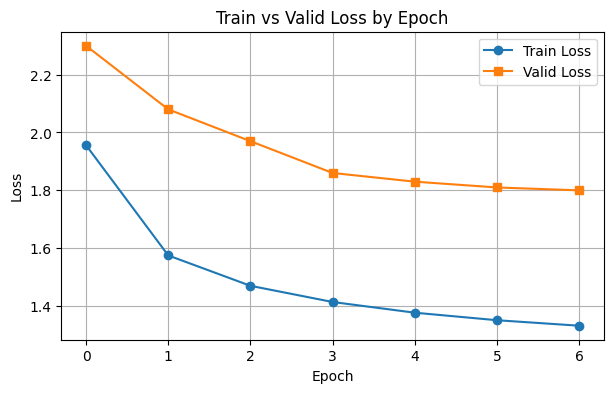

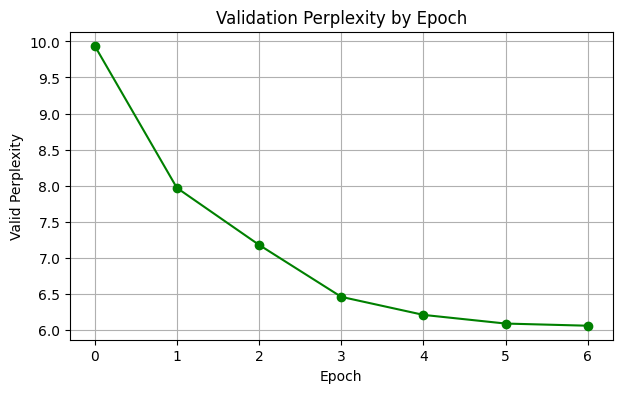

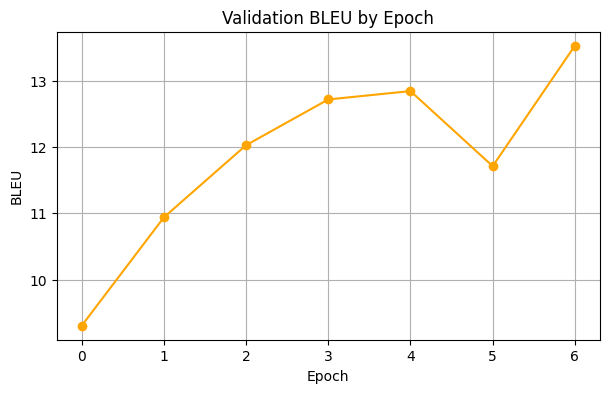

In [12]:
import matplotlib.pyplot as plt


plt.figure(figsize=(7,4))
plt.plot(df["epoch"], df["train_loss"], marker='o', label="Train Loss")
plt.plot(df["epoch"], df["valid_loss"], marker='s', label="Valid Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Valid Loss by Epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(df["epoch"], df["valid_perplexity"], marker='o', color="green")
plt.xlabel("Epoch")
plt.ylabel("Valid Perplexity")
plt.title("Validation Perplexity by Epoch")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(df["epoch"], df["BLEU"], marker='o', color="orange")
plt.xlabel("Epoch")
plt.ylabel("BLEU")
plt.title("Validation BLEU by Epoch")
plt.grid(True)
plt.show()

In [18]:
!head -n 3 news-commentary-v18.cs-en.tsv
!head -n 3 europarl-v7.cs-en.cs
!head -n 3 europarl-v7.cs-en.en

Zlato za 10 000 dolarů?	$10,000 Gold?
SAN FRANCISCO – Vést racionální rozhovor o hodnotě zlata nikdy nebylo snadné.	SAN FRANCISCO – It has never been easy to have a rational conversation about the value of gold.
V poslední době, kdy se ceny zlata zvedly o více než 300% za deset let, je to ještě těžší.	Lately, with gold prices up more than 300% over the last decade, it is harder than ever.
Následný postup na základě usnesení Parlamentu: viz zápis
Předložení dokumentů: viz zápis
Písemná prohlášení (článek 116 jednacího řádu): viz zápis
Action taken on Parliament's resolutions: see Minutes
Documents received: see Minutes
Written statements (Rule 116): see Minutes


In [19]:
!head -n 2500 europarl-v7.cs-en.cs > europarl_2500.cs
!head -n 2500 europarl-v7.cs-en.en > europarl_2500.en

In [20]:
!head -n 2500 news-commentary-v18.cs-en.tsv > news-commentary_2500.tsv